# cosmock
### An implementation of the generalized point transformations of Gaussians formalism
#### arXiv: 2411.04759
In this notebook, we will show how to use the functions in this repository. 

In [1]:
import numpy as np 
import healpy as hp 
# ================================================
path2map      = 'data/Kappa_Gower_St_ID_44_DESy3_tomography_Nside_256.npy'
path2lpmap    = 'data/Kappa_Gower_St_ID_44_DESy3_tomography_Nside_256_lowpassed_pix.npy'
path2pixwin   = 'data/pixwin_256.npy'
path2cls      = 'data/UNBIASED_3point75nsideminus1_Cls_NG_Gower_St_ID_44.npy'
N             = 3
# ================================================
kappa_map     = np.load(path2map)
kappa_map_lp  = np.load(path2lpmap)
cl_NG         = np.load(path2cls)
pixwin        = np.load(path2pixwin)
N_bins        = kappa_map.shape[0]
N_pix         = kappa_map.shape[1]
Nside         = hp.npix2nside(N_pix)   
gen_lmax      = 3*Nside-1   
lmax          = 2*Nside


In [2]:
from cosmock.wrappers import fit_parameters,generate_mocks

parameters = fit_parameters(kappa_map,cl_NG,N)
mocks      = generate_mocks(parameters,1,pixwin)

Done fitting the G3 parameters
Done finding the power spectrum of the underlying gaussian random field


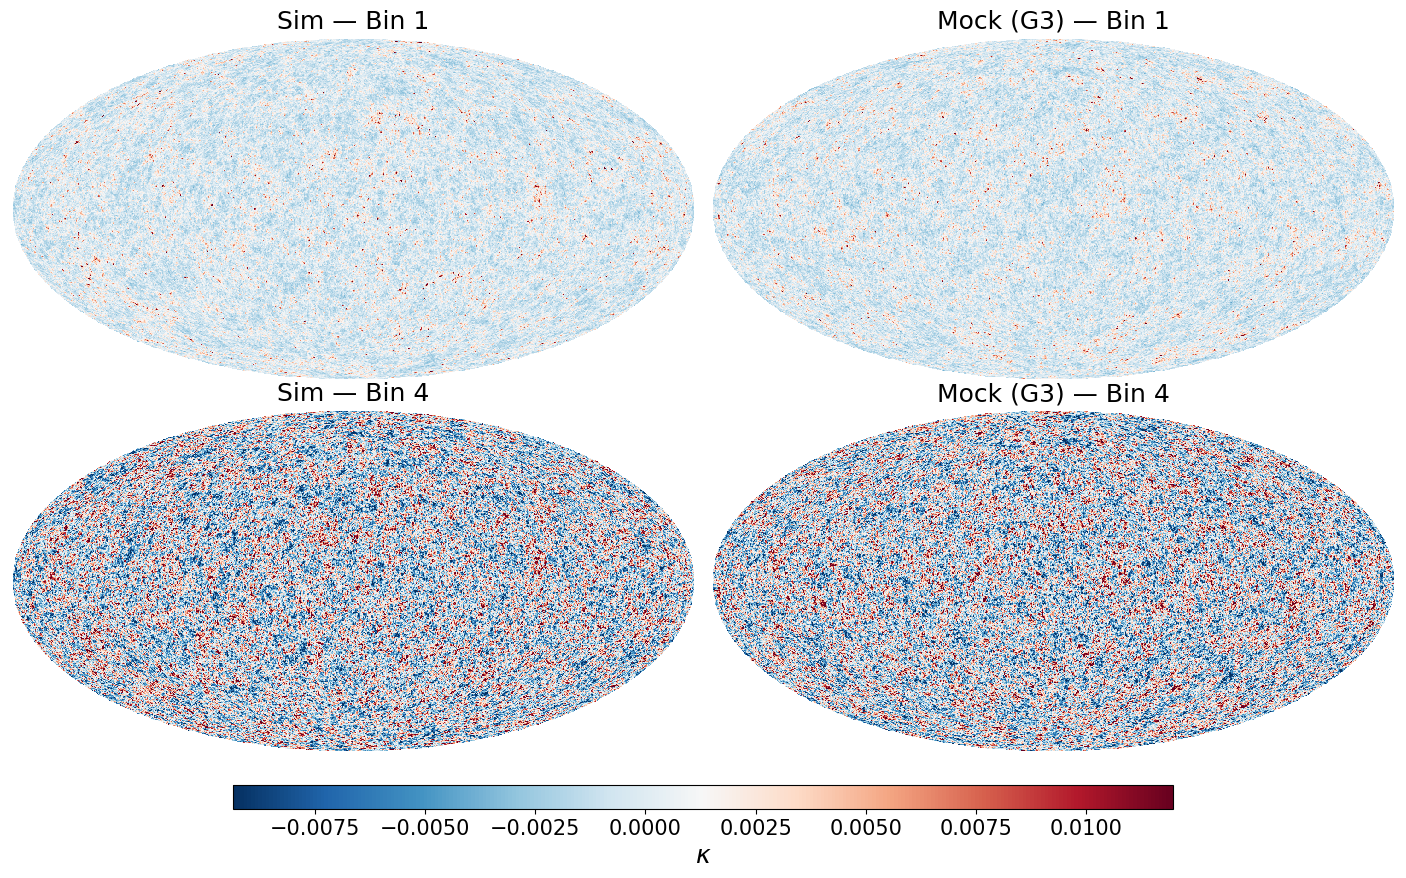

In [3]:
import matplotlib.pyplot as plt 
kappa_mock_pix = mocks[0]
bin_indices = [0, 3]
bin_labels  = ['Bin 1', 'Bin 4']

vmin = np.percentile(kappa_map_lp[bin_indices], 1)
vmax = np.percentile(kappa_map_lp[bin_indices], 99)

fig = plt.figure(figsize=(14, 8))

for row, (idx, label) in enumerate(zip(bin_indices, bin_labels)):
    hp.mollview(
        kappa_map_lp[idx],
        fig=fig.number, sub=(2, 2, 2*row + 1),
        title=f'Sim — {label}',
        min=vmin, max=vmax,
        cmap='RdBu_r', notext=True, cbar=False,
    )
    hp.mollview(
        kappa_mock_pix[idx],
        fig=fig.number, sub=(2, 2, 2*row + 2),
        title=f'Mock (G{N}) — {label}',
        min=vmin, max=vmax,
        cmap='RdBu_r', notext=True, cbar=False,
    )

for ax in fig.axes:
    ax.title.set_fontsize(18)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=fig.axes, orientation='horizontal',
                    fraction=0.03, pad=0.04, aspect=40)
cbar.set_label(r'$\kappa$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

plt.show()
plt.close()

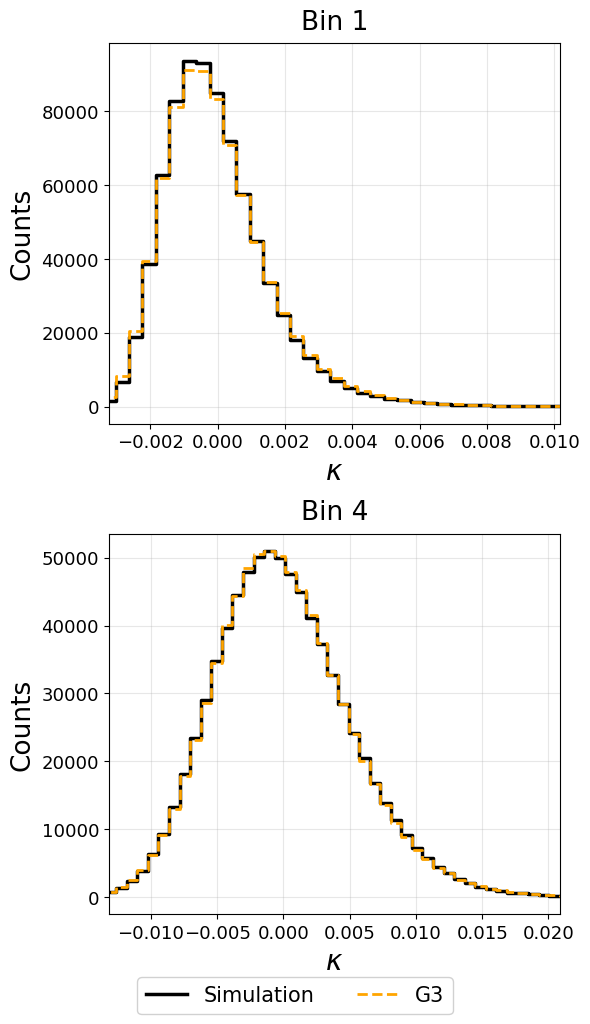

In [4]:
bin_indices = [0, 3]
bin_labels  = ['Bin 1', 'Bin 4']

fig, axes = plt.subplots(2, 1, figsize=(6, 10))

for row, (idx, label) in enumerate(zip(bin_indices, bin_labels)):
    ax = axes[row]

    counts_sim, bins = np.histogram(kappa_map_lp[idx], bins=100)
    counts_n3,  _    = np.histogram(kappa_mock_pix[idx], bins=bins)

    ax.step(bins[:-1], counts_sim, where='post', color='black', lw=2.5, label='Simulation')
    ax.step(bins[:-1], counts_n3,  where='post', color='orange', lw=2,   ls='dashed', label=f'G{N}')
    ax.set_ylabel('Counts', fontsize=19)
    ax.set_xlabel(r'$\kappa$', fontsize=20)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=13)
    ax.set_title(label, fontsize=19, pad=10)

    xlo = np.percentile(kappa_map_lp[idx], 0.1)
    xhi = np.percentile(kappa_map_lp[idx], 99.9)
    ax.set_xlim(xlo, xhi)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.03),
           ncol=3, fontsize=15, framealpha=0.9)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()
plt.close()

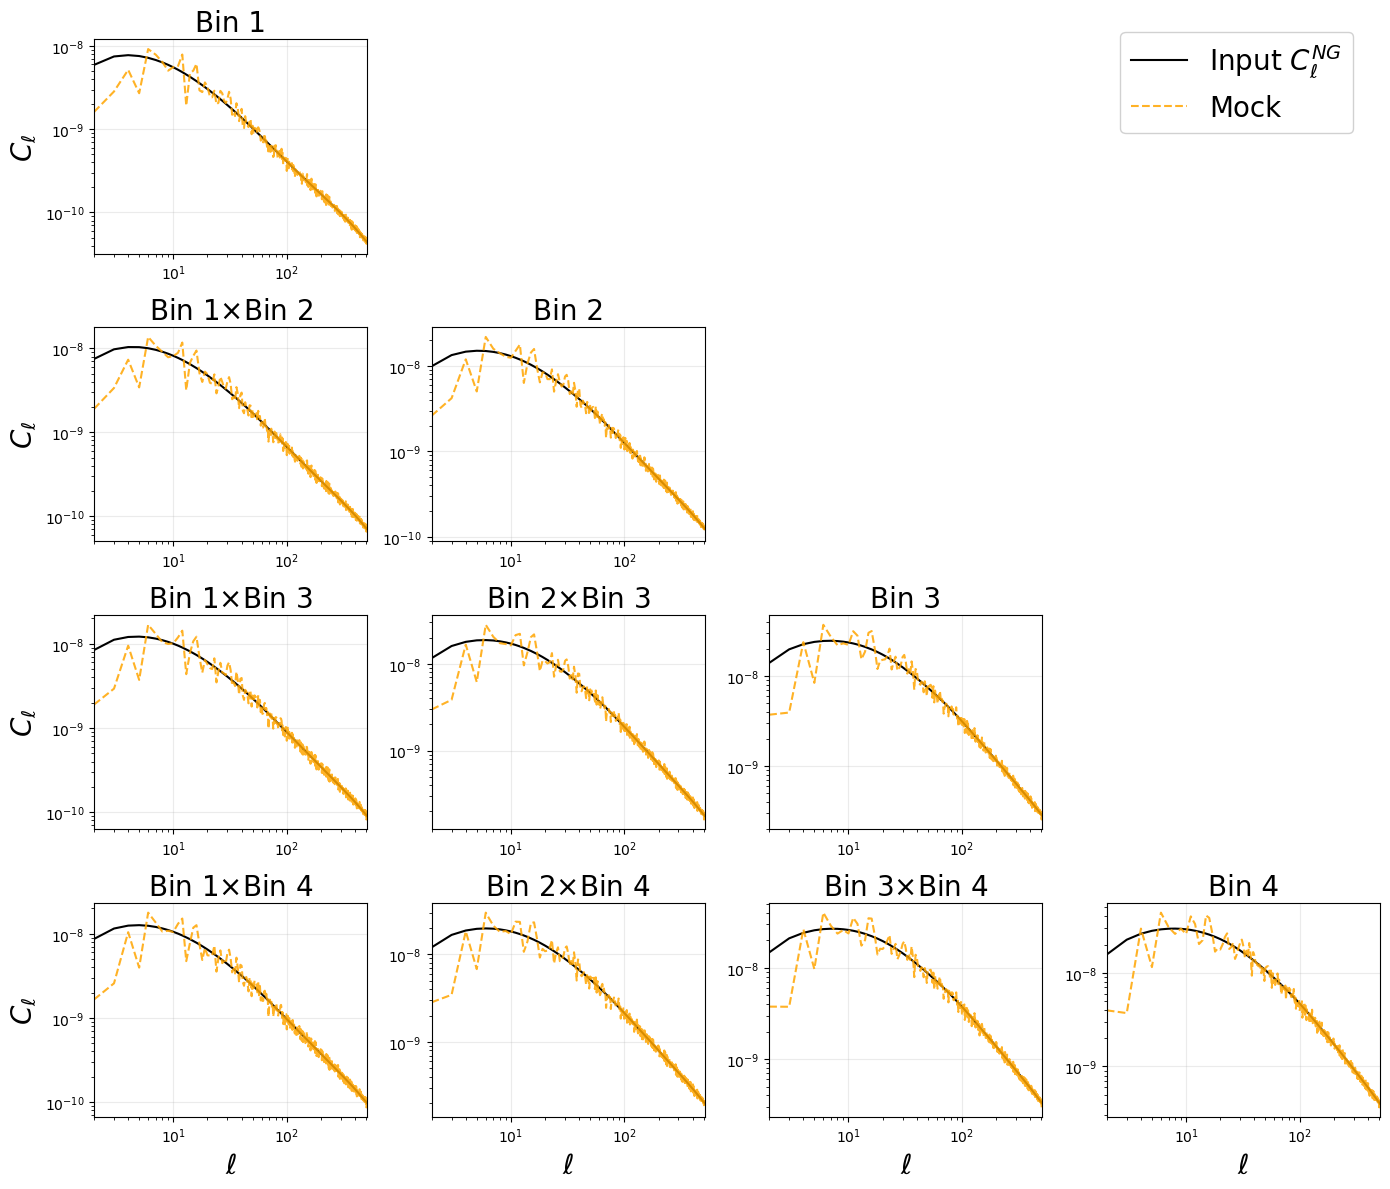

In [5]:
ells = np.arange(lmax + 1)
l2   = ells >= 2   
cl_mock = {}
for i in range(N_bins):
    for j in range(i + 1):
        if i == j:
            cl_mock[(i, j)] = hp.anafast(kappa_mock_pix[i], lmax=lmax)
        else:
            cl_mock[(i, j)] = hp.anafast(kappa_mock_pix[i], kappa_mock_pix[j], lmax=lmax)

pw = pixwin[:lmax + 1]

fig, axes = plt.subplots(N_bins, N_bins, figsize=(14, 12))

for i in range(N_bins):
    for j in range(N_bins):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue

        cl_in  = cl_NG[i, j, :lmax + 1] * (pw ** 2)
        cl_out = cl_mock[(i, j)] 
        pos = l2 & (cl_out > 0) & (cl_in > 0)
        ax.loglog(ells[pos], cl_in[pos],  color='k',       lw=1.5, label=r'Input $C_\ell^{NG}$')
        ax.loglog(ells[pos], cl_out[pos], color='orange', lw=1.5, ls='--', alpha=0.85, label='Mock')

        ax.set_xlim(2, lmax)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=10)

        title = rf'Bin {j+1}$\times$Bin {i+1}' if i != j else rf'Bin {i+1}'
        ax.set_title(title, fontsize=20)

        if j == 0:
            ax.set_ylabel(r'$C_\ell$', fontsize=20)
        if i == N_bins - 1:
            ax.set_xlabel(r'$\ell$', fontsize=20)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98),
           fontsize=20, framealpha=0.9)
plt.tight_layout()
plt.show()
plt.close()
